In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
path = '/Users/zamiulalam/Documents/Informatics_Project/mimic_processed_data/mimic3-benchmarks/data/root/all_stays.csv'

stays = pd.read_csv(path)

In [3]:
stays.shape

(42276, 20)

In [4]:
stays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42276 entries, 0 to 42275
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SUBJECT_ID            42276 non-null  int64  
 1   HADM_ID               42276 non-null  int64  
 2   ICUSTAY_ID            42276 non-null  int64  
 3   LAST_CAREUNIT         42276 non-null  object 
 4   DBSOURCE              42276 non-null  object 
 5   INTIME                42276 non-null  object 
 6   OUTTIME               42273 non-null  object 
 7   LOS                   42273 non-null  float64
 8   ADMITTIME             42276 non-null  object 
 9   DISCHTIME             42276 non-null  object 
 10  DEATHTIME             4523 non-null   object 
 11  ETHNICITY             42276 non-null  object 
 12  DIAGNOSIS             42275 non-null  object 
 13  GENDER                42276 non-null  object 
 14  DOB                   42276 non-null  object 
 15  DOD                

In [5]:
#Find the number of missing values in each column
missing_values = stays.isnull().sum()

#Turn the missing value counts into percentages
missing_values_percentage = (missing_values / len(stays)) * 100

#Return counts and percentages of missing values in each column
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})

missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
DEATHTIME,37753,89.301258
DOD,24073,56.942473
OUTTIME,3,0.007096
LOS,3,0.007096
DIAGNOSIS,1,0.002365
ETHNICITY,0,0.000000
MORTALITY,0,0.000000
MORTALITY_INUNIT,0,0.000000
AGE,0,0.000000
DOB,0,0.000000


In [6]:
stays.describe()

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,LOS,AGE,MORTALITY_INUNIT,MORTALITY,MORTALITY_INHOSPITAL
count,42276.000000,42276.000000,42276.000000,42273.000000,42276.000000,42276.000000,42276.000000,42276.000000
mean,36730.136981,150055.087946,250092.846130,3.607728,74.997177,0.084658,0.106278,0.106278
std,29014.194921,28931.850616,28934.330583,5.192107,55.806009,0.278375,0.308196,0.308196
min,3.000000,100001.000000,200001.000000,0.000200,18.034034,0.000000,0.000000,0.000000
25%,13235.500000,124907.000000,224982.250000,1.151900,52.435975,0.000000,0.000000,0.000000
50%,26606.500000,150216.500000,250047.500000,2.007200,65.524698,0.000000,0.000000,0.000000
75%,60015.500000,175160.250000,275239.500000,3.736300,77.855761,0.000000,0.000000,0.000000
max,99999.000000,199999.000000,299999.000000,116.832700,310.486582,1.000000,1.000000,1.000000


In [7]:
stays.sample(10)

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,LAST_CAREUNIT,DBSOURCE,INTIME,OUTTIME,LOS,ADMITTIME,DISCHTIME,DEATHTIME,ETHNICITY,DIAGNOSIS,GENDER,DOB,DOD,AGE,MORTALITY_INUNIT,MORTALITY,MORTALITY_INHOSPITAL
36629,73997,195629,218713,SICU,metavision,2164-03-21 23:22:53,2164-03-22 17:52:21,0.7705,2164-03-21 21:38:00,2164-03-29 18:00:00,NaN,WHITE,ABDOMINAL PAIN,F,2094-02-10 00:00:00,2164-07-10 00:00:00,70.156094,0,0,0
7218,6536,123424,228563,TSICU,carevue,2160-05-23 15:30:32,2160-05-26 21:20:22,3.2429,2160-05-23 15:29:00,2160-05-29 16:00:00,NaN,WHITE,ABDOMINAL AORTIC ANEURYSM,M,2120-11-07 00:00:00,NaN,39.568894,0,0,0
39826,98195,155149,201281,TSICU,metavision,2175-10-11 12:02:58,2175-10-12 20:31:10,1.3529,2175-10-11 12:02:00,2175-10-17 13:15:00,NaN,PATIENT DECLINED TO ANSWER,BLUNT TRAUMA,M,2089-12-29 00:00:00,2177-09-07 00:00:00,85.839732,0,0,0
21200,25557,194196,234411,CCU,metavision,2128-02-25 12:28:03,2128-02-27 18:10:46,2.2380,2128-02-25 12:27:00,2128-02-27 15:30:00,NaN,WHITE,ATRIAL FIBRILLATION;BRADYCARDIA;AORTIC STENOSIS,F,2052-02-13 00:00:00,NaN,76.083615,0,0,0
20630,25933,169968,254563,MICU,metavision,2152-08-27 19:51:02,2152-08-29 15:16:55,1.8096,2152-08-27 19:50:00,2152-09-01 20:40:00,NaN,WHITE,OVERDOSE,F,2115-03-12 00:00:00,2154-12-31 00:00:00,37.489937,0,0,0
331,644,124257,202475,TSICU,carevue,2130-05-18 16:04:14,2130-05-19 12:08:59,0.8366,2130-05-18 07:24:00,2130-05-26 14:30:00,NaN,ASIAN,HYPOTHERMIA/SEIZURE,F,2066-08-02 00:00:00,NaN,63.834711,0,0,0
31848,51004,198447,256580,CSRU,metavision,2159-04-23 11:02:31,2159-04-23 11:59:39,0.0397,2159-04-23 07:45:00,2159-04-23 14:00:00,NaN,WHITE,THORACIC ANEURYSM/SDA,M,2086-01-17 00:00:00,NaN,73.310850,0,0,0
9301,15374,165280,285132,MICU,carevue,2133-04-30 20:12:00,2133-05-03 21:32:00,3.0556,2133-04-28 15:05:00,2133-05-07 14:27:00,NaN,BLACK/AFRICAN AMERICAN,HEMOPTYSIS; PROBABLE ASPERGILLONA,M,2098-06-24 00:00:00,2143-06-17 00:00:00,34.873539,0,0,0
39105,82127,173722,214234,SICU,metavision,2110-08-06 16:06:43,2110-08-07 15:09:19,0.9601,2110-08-06 11:45:00,2110-08-10 14:40:00,NaN,WHITE,MENINGOMA/SDA,F,2053-04-16 00:00:00,NaN,57.344305,0,0,0
12557,17687,145883,203944,CSRU,carevue,2190-02-23 12:36:00,2190-02-24 12:02:00,0.9764,2190-02-23 07:15:00,2190-02-27 11:34:00,NaN,UNKNOWN/NOT SPECIFIED,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,M,2129-04-30 00:00:00,NaN,60.861712,0,0,0


Number of unique patients

In [8]:
len(stays['SUBJECT_ID'].unique())

33798

Number of unique hospital admissions

In [18]:
len(stays['HADM_ID'].unique())

42276

Total number of stays

In [9]:
len(stays['ICUSTAY_ID'].unique())

42276

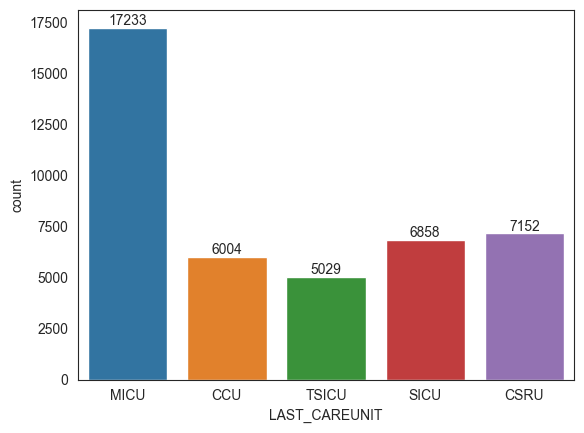

In [43]:
ax = sns.countplot(x='LAST_CAREUNIT', data=stays, hue='LAST_CAREUNIT')
#plt.title('LAST_CAREUNIT')

for container in ax.containers:
    ax.bar_label(container) # type: ignore

plt.show()

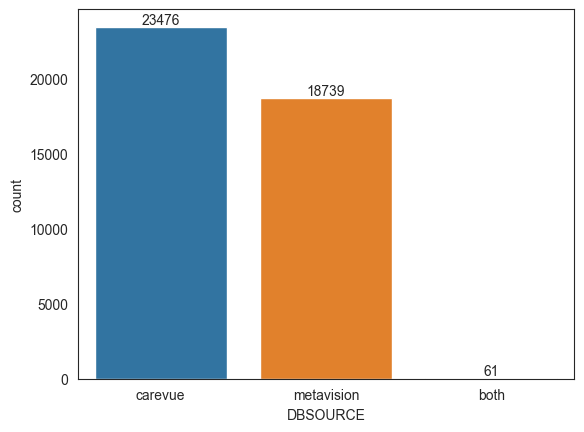

In [44]:
ax = sns.countplot(x='DBSOURCE', data=stays, hue='DBSOURCE')

for container in ax.containers:
    ax.bar_label(container)  # type: ignore

plt.show()

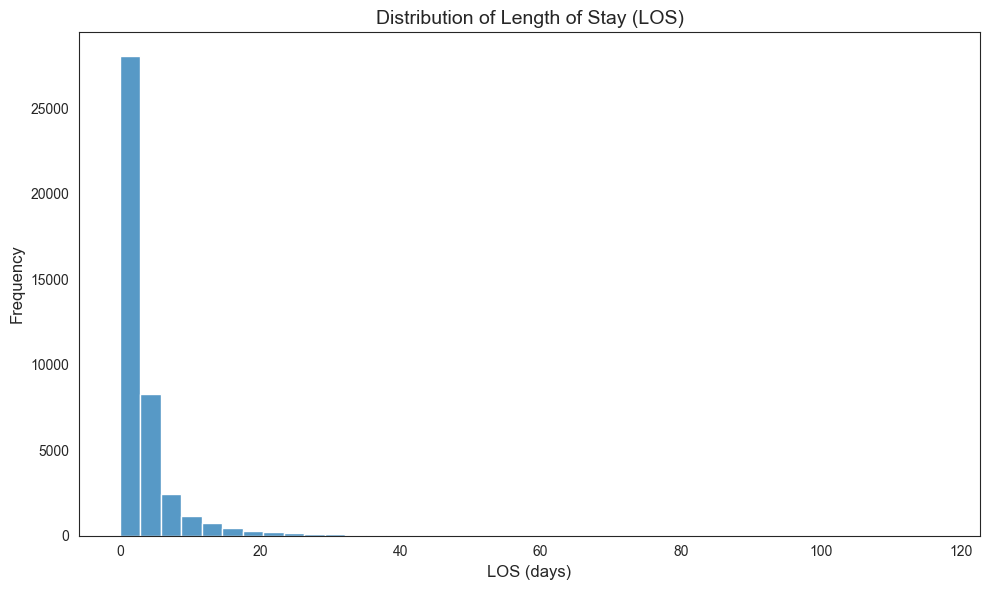

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(data=stays, x='LOS',bins=40)
plt.title('Distribution of Length of Stay (LOS)', fontsize=14)
plt.xlabel('LOS (days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

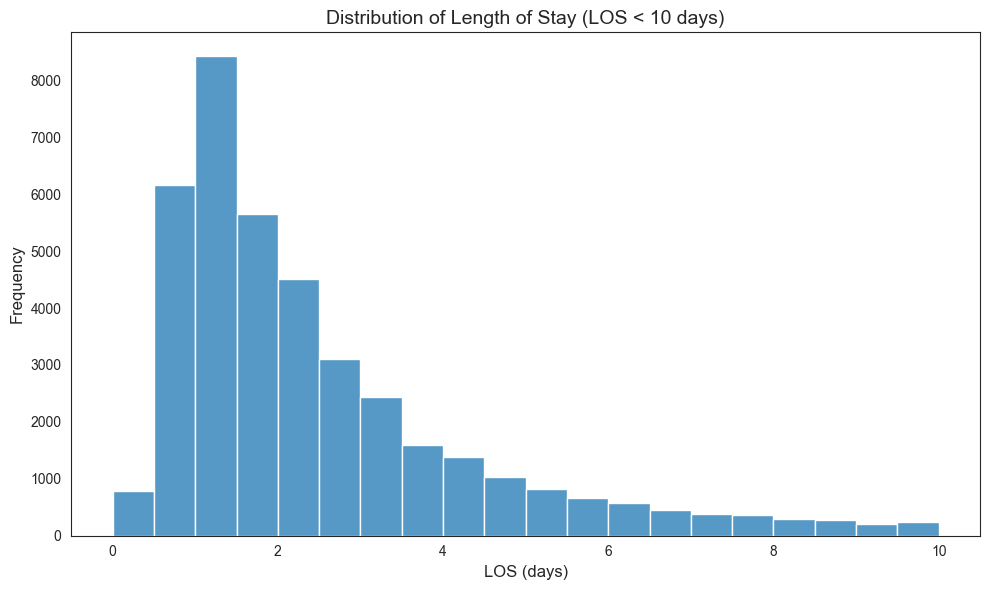

In [51]:
plt.figure(figsize=(10, 6))

# Filter for LOS < 10
los_filtered = stays[stays['LOS'] < 10]

sns.histplot(data=los_filtered, x='LOS', bins=20)

plt.title('Distribution of Length of Stay (LOS < 10 days)', fontsize=14)
plt.xlabel('LOS (days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

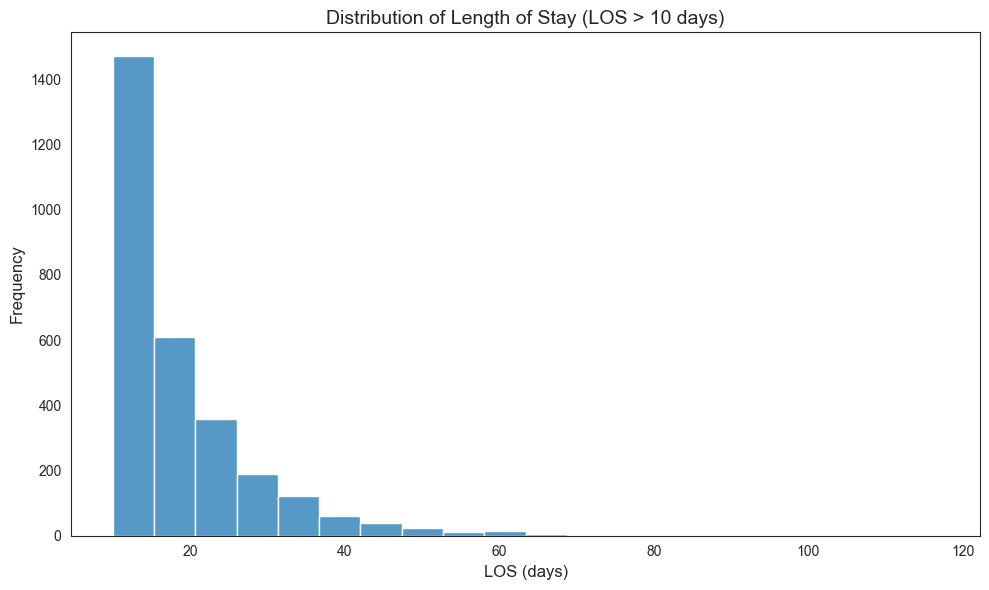

In [52]:
plt.figure(figsize=(10, 6))

# Filter for LOS > 10
los_filtered = stays[stays['LOS'] > 10]

sns.histplot(data=los_filtered, x='LOS', bins=20)

plt.title('Distribution of Length of Stay (LOS > 10 days)', fontsize=14)
plt.xlabel('LOS (days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

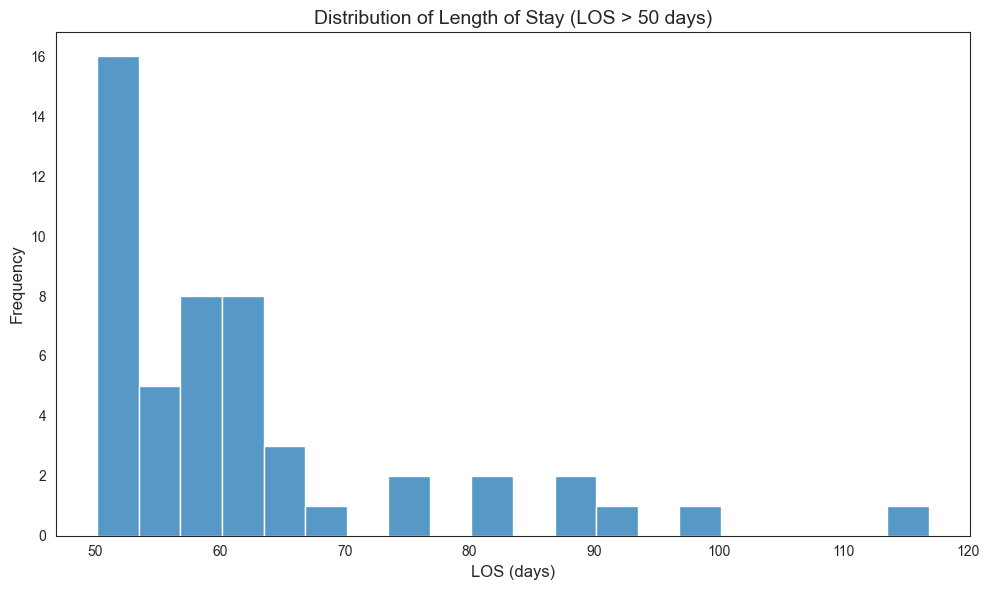

In [53]:
plt.figure(figsize=(10, 6))

# Filter for LOS > 50
los_filtered = stays[stays['LOS'] > 50]

sns.histplot(data=los_filtered, x='LOS', bins=20)

plt.title('Distribution of Length of Stay (LOS > 50 days)', fontsize=14)
plt.xlabel('LOS (days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
stays.head(10)

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,LAST_CAREUNIT,DBSOURCE,INTIME,OUTTIME,LOS,ADMITTIME,DISCHTIME,DEATHTIME,ETHNICITY,DIAGNOSIS,GENDER,DOB,DOD,AGE,MORTALITY_INUNIT,MORTALITY,MORTALITY_INHOSPITAL
0,268,110404,280836,MICU,carevue,2198-02-14 23:27:38,2198-02-18 05:26:11,3.2490,2198-02-11 13:40:00,2198-02-18 03:55:00,2198-02-18 03:55:00,HISPANIC OR LATINO,DYSPNEA,F,2132-02-21 00:00:00,2198-02-18 00:00:00,66.030075,1,1,1
1,269,106296,206613,MICU,carevue,2170-11-05 11:05:29,2170-11-08 17:46:57,3.2788,2170-11-05 11:04:00,2170-11-27 18:00:00,NaN,WHITE,SEPSIS;PILONIDAL ABSCESS,M,2130-09-30 00:00:00,NaN,40.127294,0,0,0
2,270,188028,220345,CCU,carevue,2128-06-24 15:05:20,2128-06-27 12:32:29,2.8939,2128-06-23 18:26:00,2128-06-27 12:31:00,NaN,UNKNOWN/NOT SPECIFIED,CAROTID STENOSIS\CAROTID ANGIOGRAM AND STENT,M,2048-05-26 00:00:00,NaN,80.133229,0,0,0
3,272,164716,210407,CCU,carevue,2186-12-25 21:08:04,2186-12-27 12:01:13,1.6202,2186-12-25 21:06:00,2187-01-02 14:57:00,NaN,WHITE,PULMONARY EMBOLIS,M,2119-11-21 00:00:00,NaN,67.142139,0,0,0
4,273,158689,241507,MICU,carevue,2141-04-19 06:12:05,2141-04-20 17:52:11,1.4862,2141-04-19 06:11:00,2141-04-20 17:00:00,NaN,BLACK/AFRICAN AMERICAN,POLYSUBSTANCE OVERDOSE,M,2107-08-10 00:00:00,NaN,33.715776,0,0,0
5,274,130546,254851,MICU,carevue,2114-06-28 22:28:44,2114-07-07 18:01:16,8.8143,2114-06-28 22:16:00,2114-07-12 15:30:00,NaN,BLACK/AFRICAN AMERICAN,SUBARACHNOID HEMORRHAGE,M,2048-05-18 00:00:00,2122-09-07 00:00:00,66.155991,0,0,0
6,275,129886,219649,CCU,carevue,2170-10-07 11:28:53,2170-10-14 14:38:07,7.1314,2170-10-06 03:09:00,2170-10-19 15:35:00,2170-10-19 15:35:00,WHITE,UROSEPSIS-CHANGE IN MENTAL STATUS,M,2088-08-07 00:00:00,2170-10-19 00:00:00,82.220489,0,1,1
7,276,135156,206327,CCU,carevue,2147-11-20 09:02:23,2147-11-21 17:08:52,1.3378,2147-11-19 16:53:00,2147-11-22 13:15:00,NaN,WHITE,GASTROINTESTINAL BLEED,M,2112-01-16 00:00:00,NaN,35.869525,0,0,0
8,279,192224,204407,MICU,carevue,2164-06-14 21:18:27,2164-06-18 22:53:12,4.0658,2164-06-13 19:19:00,2164-06-19 17:15:00,NaN,WHITE,ENDOSCOPIC RETROGRADE CHOLANGIOPANCREATOGRAPHY...,M,2090-02-27 00:00:00,2164-06-27 00:00:00,74.344898,0,0,0
9,281,111199,257572,MICU,carevue,2101-10-18 04:45:22,2101-10-25 22:29:25,7.7389,2101-10-18 04:42:00,2101-10-25 19:10:00,2101-10-25 19:10:00,BLACK/AFRICAN AMERICAN,"PNEUMONIA,HYPONATREMIA",F,2041-10-12 00:00:00,2101-10-25 00:00:00,60.055337,1,1,1


In [13]:
len(stays['ETHNICITY'].unique())

41

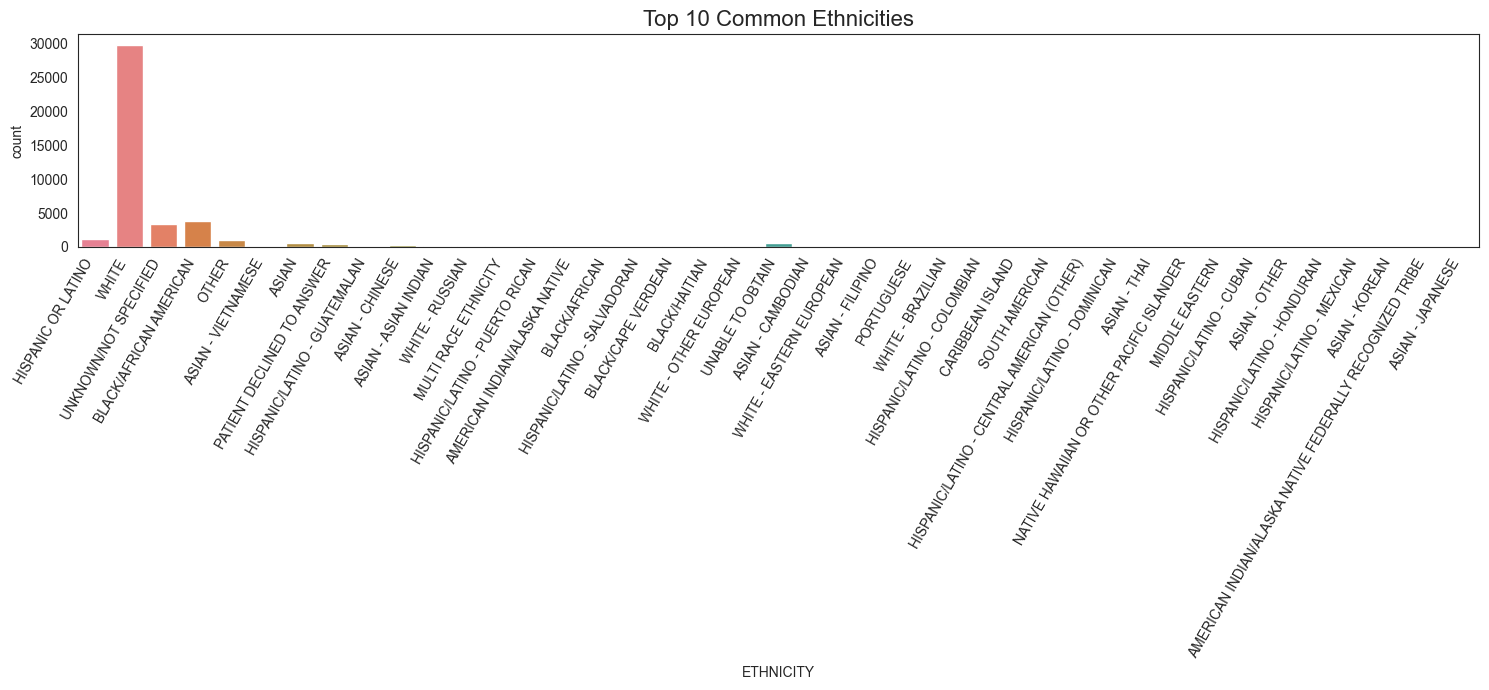

In [39]:
plt.figure(figsize=(15, 7))
sns.set_style("white")

sns.countplot(x=stays['ETHNICITY'], hue= stays['ETHNICITY'], legend=False)
plt.title('Top 10 Common Ethnicities', fontsize=16)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

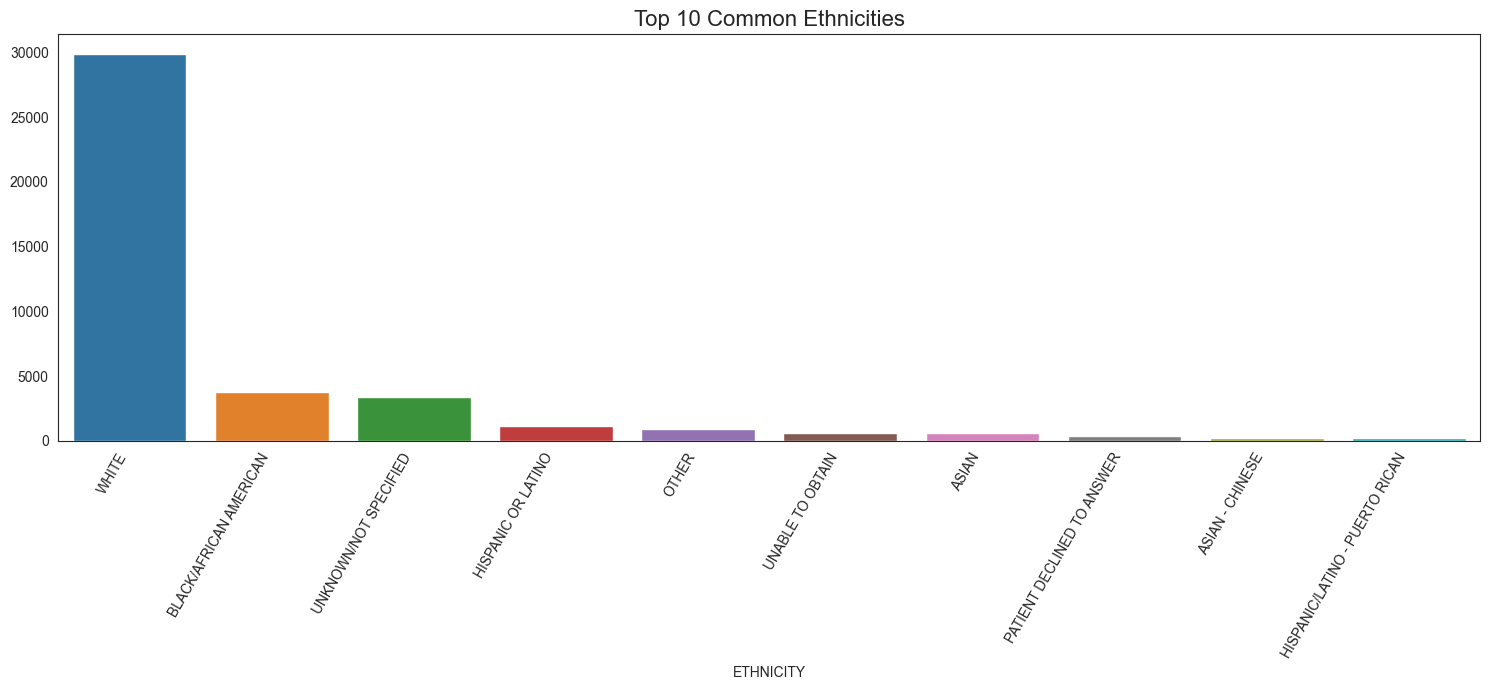

In [46]:
top_ethnicity = stays['ETHNICITY'].value_counts().head(10)

plt.figure(figsize=(15, 7))
sns.set_style("white")

sns.barplot(x=top_ethnicity.index, y=top_ethnicity.values, hue= top_ethnicity.index, legend=False)
plt.title('Top 10 Common Ethnicities', fontsize=16)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

In [45]:
len(stays['DIAGNOSIS'].unique())

13166

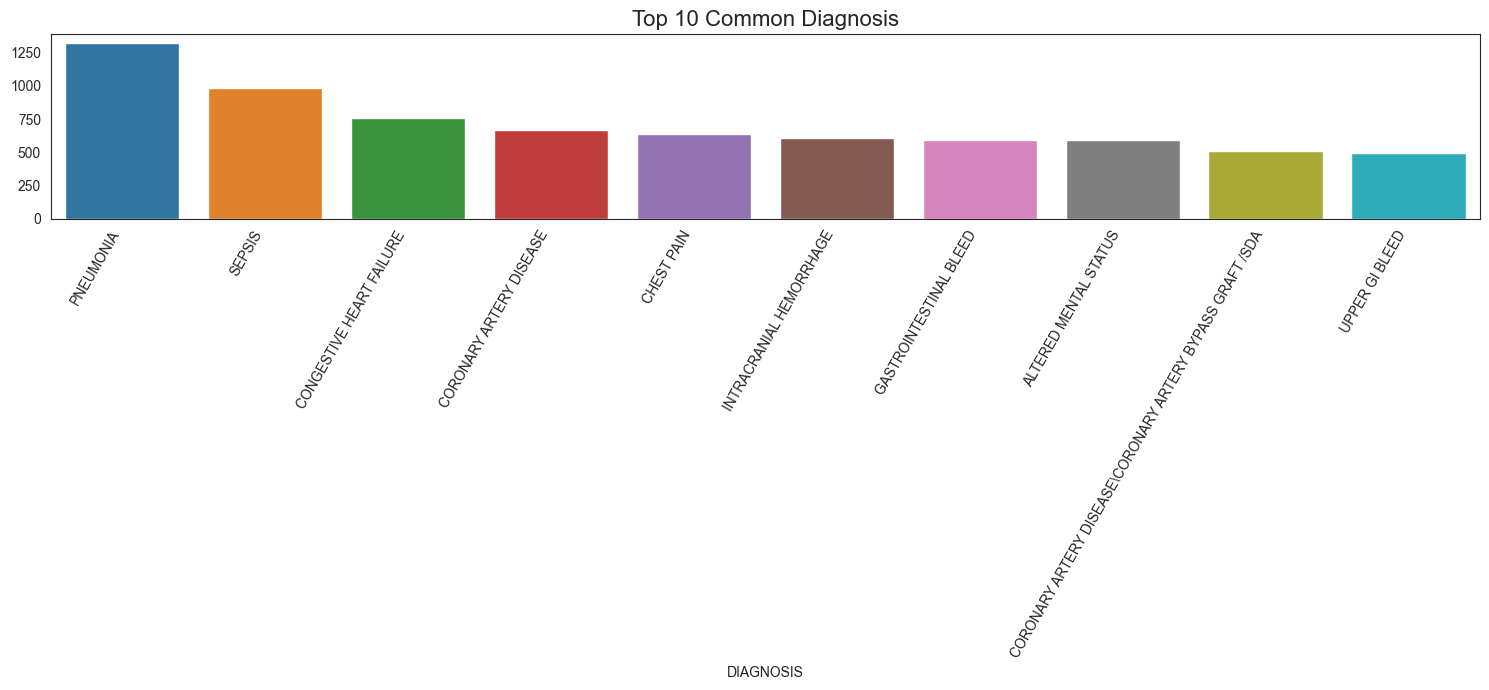

In [48]:
top_diagnosis = stays['DIAGNOSIS'].value_counts().head(10)

plt.figure(figsize=(15, 7))
sns.set_style("white")

sns.barplot(x=top_diagnosis.index, y=top_diagnosis.values, hue= top_diagnosis.index, legend=False)
plt.title('Top 10 Common Diagnosis', fontsize=16)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

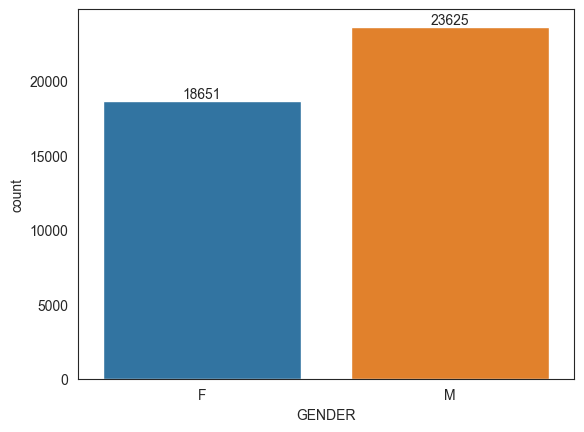

In [50]:
ax = sns.countplot(x='GENDER', data=stays, hue='GENDER')

for container in ax.containers:
    ax.bar_label(container)  # type: ignore

plt.show()

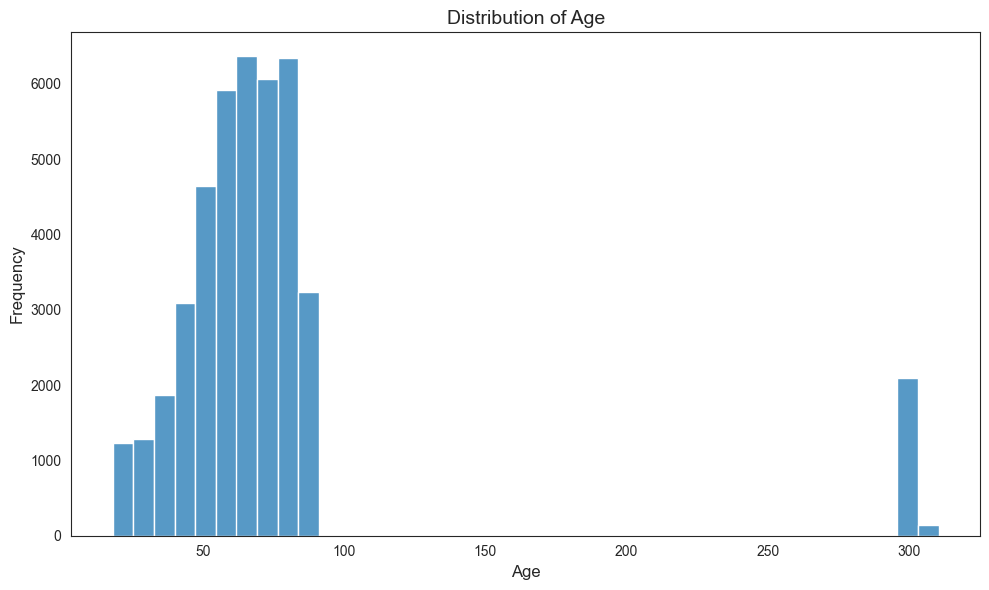

In [56]:
plt.figure(figsize=(10, 6))
sns.histplot(data=stays, x='AGE',bins=40)
plt.title('Distribution of Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [57]:
stays.head()

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,LAST_CAREUNIT,DBSOURCE,INTIME,OUTTIME,LOS,ADMITTIME,DISCHTIME,DEATHTIME,ETHNICITY,DIAGNOSIS,GENDER,DOB,DOD,AGE,MORTALITY_INUNIT,MORTALITY,MORTALITY_INHOSPITAL
0,268,110404,280836,MICU,carevue,2198-02-14 23:27:38,2198-02-18 05:26:11,3.2490,2198-02-11 13:40:00,2198-02-18 03:55:00,2198-02-18 03:55:00,HISPANIC OR LATINO,DYSPNEA,F,2132-02-21 00:00:00,2198-02-18 00:00:00,66.030075,1,1,1
1,269,106296,206613,MICU,carevue,2170-11-05 11:05:29,2170-11-08 17:46:57,3.2788,2170-11-05 11:04:00,2170-11-27 18:00:00,NaN,WHITE,SEPSIS;PILONIDAL ABSCESS,M,2130-09-30 00:00:00,NaN,40.127294,0,0,0
2,270,188028,220345,CCU,carevue,2128-06-24 15:05:20,2128-06-27 12:32:29,2.8939,2128-06-23 18:26:00,2128-06-27 12:31:00,NaN,UNKNOWN/NOT SPECIFIED,CAROTID STENOSIS\CAROTID ANGIOGRAM AND STENT,M,2048-05-26 00:00:00,NaN,80.133229,0,0,0
3,272,164716,210407,CCU,carevue,2186-12-25 21:08:04,2186-12-27 12:01:13,1.6202,2186-12-25 21:06:00,2187-01-02 14:57:00,NaN,WHITE,PULMONARY EMBOLIS,M,2119-11-21 00:00:00,NaN,67.142139,0,0,0
4,273,158689,241507,MICU,carevue,2141-04-19 06:12:05,2141-04-20 17:52:11,1.4862,2141-04-19 06:11:00,2141-04-20 17:00:00,NaN,BLACK/AFRICAN AMERICAN,POLYSUBSTANCE OVERDOSE,M,2107-08-10 00:00:00,NaN,33.715776,0,0,0


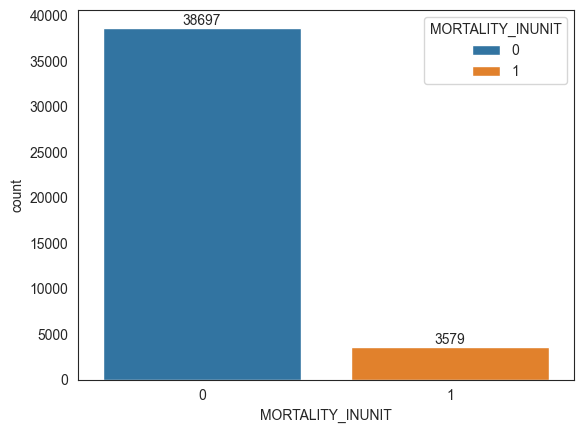

In [58]:
ax = sns.countplot(x='MORTALITY_INUNIT', data=stays, hue='MORTALITY_INUNIT')

for container in ax.containers:
    ax.bar_label(container)  # type: ignore

plt.show()

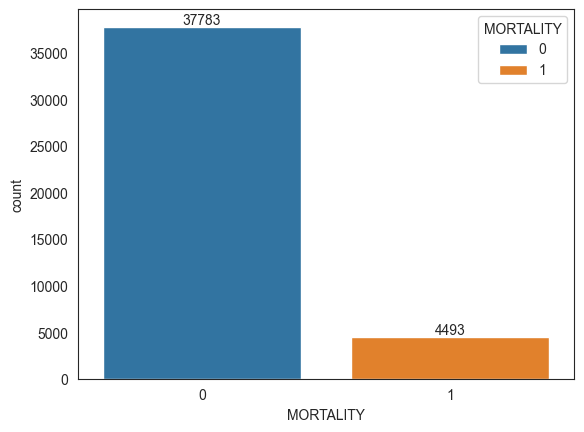

In [59]:
ax = sns.countplot(x='MORTALITY', data=stays, hue='MORTALITY')

for container in ax.containers:
    ax.bar_label(container)  # type: ignore

plt.show()

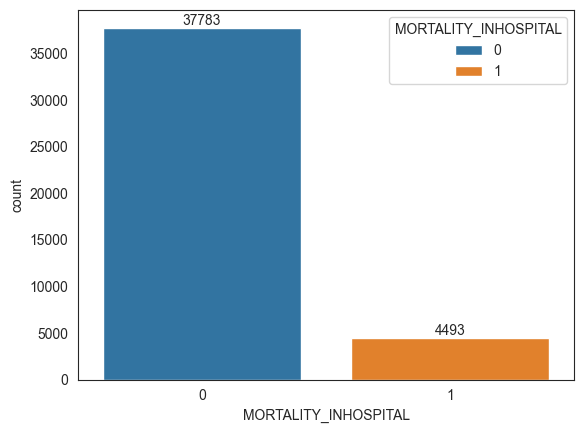

In [60]:
ax = sns.countplot(x='MORTALITY_INHOSPITAL', data=stays, hue='MORTALITY_INHOSPITAL')

for container in ax.containers:
    ax.bar_label(container)  # type: ignore

plt.show()